In [1]:
import torch
import argparse
from stpy.helpers.helper import cartesian
from PIL import Image
import time

from doexpy.env.llm import LLMGrid, get_scorer_model
from doexpy.functionals.doe_static_functionals import DesignA, DesignD, MultiPolicyAggDesignA
from doexpy.mdpexplore import MdpExplore, MdpExploreMultiPolicy
from doexpy.convex_solvers.frank_wolfe import FrankWolfe
from doexpy.feedback.feedback_base import EmptyFeedback
from doexpy.solvers.dp import DP
from doexpy.policies.summary_policies.density_policy import DensityPolicy

from stpy.regression.kernelized_features import KernelizedFeatures
from stpy.regression.regularized_dictionary.regularized_multinomial_estimator import RegularizedMultinomialEstimator
from stpy.probability.multinomial_likelihood import MultinomialLikelihood
from stpy.regularization.regularizer import L2Regularizer
from stpy.embeddings.polynomial_embedding import CustomEmbedding
from doexpy.env.llm import LLMGrid, CLIPEmbedder, DotProductModel, ImageScorer, create_prompt, setup_clip_model, make_theta_star, get_scorer_model

import torch.nn as nn
import numpy as np

2025-01-21 14:12:36.753979: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-21 14:12:36.755474: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-21 14:12:36.790130: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-21 14:12:37.301371: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
file_path = '../mediums.txt'
with open(file_path, 'r') as file:
    words_list_1 = [line.strip() for line in file]

#file_path = 'movements_small.txt'
file_path = '../movements.txt'
with open(file_path, 'r') as file:
    words_list_2 = [line.strip() for line in file]

#file_path = 'movements_small.txt'
file_path = '../claude.txt'
with open(file_path, 'r') as file:
    words_list_3 = [line.strip() for line in file]

#file_path = 'movements_small.txt'
file_path = '../diverse.txt'
with open(file_path, 'r') as file:
    words_list_4 = [line.strip() for line in file]

In [3]:
clip_model, clip_processor, clip_tokenizer = setup_clip_model(".")

In [4]:
horizon = 3
allowed_words_per_timestep = [words_list_1 + words_list_2 + words_list_3 + words_list_4]*horizon

len(allowed_words_per_timestep)

3

In [5]:
clip_embedder = CLIPEmbedder(clip_tokenizer, clip_model)

# Prepare word lists based on algorithm type
token_lists = allowed_words_per_timestep

# Initialize environment 
env = LLMGrid(token_lists, clip_model, clip_processor, clip_tokenizer, cache_dir = ".")

scorer_model = get_scorer_model("aesthetics", clip_embedder, clip_model, clip_processor, ".")
theta_star = make_theta_star(env, scorer_model)

/home/mojko/anaconda3/lib/python3.10/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))
/home/mojko/Documents

In [6]:
# emissions
X = env.emissions
w = scorer_model.weight.T.to("cpu")
print (torch.sum(w**2))

tensor(647.7140, dtype=torch.float64)


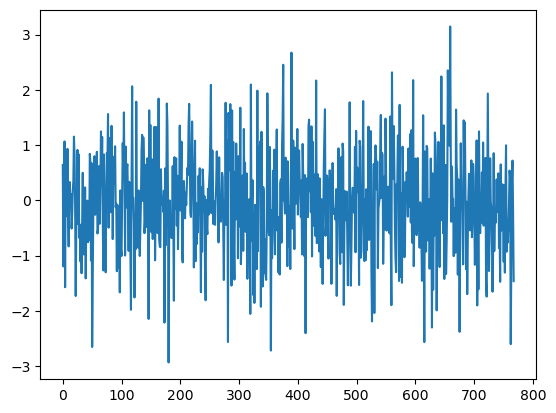

In [7]:
import matplotlib.pyplot as plt
plt.plot(w)

In [11]:
row_norms = torch.norm(X, p=2, dim=1, keepdim=True)
X_normalized = X / row_norms
X_normalized = X_normalized.to("cpu")

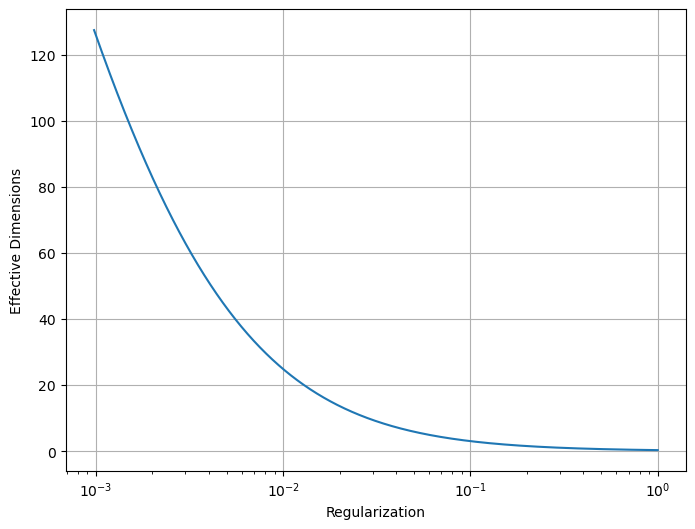

In [14]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Step 1: Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_normalized)
eigenvalues = pca.explained_variance_

# Step 2: Plot the first two principal components
plt.figure(figsize=(8, 6))
# plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
# plt.title('PCA - First Two Principal Components')

plt.xlabel('Regularization')
plt.ylabel('Effective Dimensions')

# Step 3: Calculate the effective dimension with lambda = 1
# The effective dimension is the number of principal components with eigenvalue >= 1


# Count how many eigenvalues are >= 1
lambdas = np.logspace(-10,0,1000, base = 2).reshape(1,-1)
r = 1/(eigenvalues.reshape(-1,1)+ lambdas.reshape(1,-1))
#print (eigenvalues.shape, r.shape)
effective_dimension = np.einsum('i,ij->j',eigenvalues.reshape(-1),r)
plt.semilogx(lambdas.reshape(-1),effective_dimension)
plt.grid(True)
plt.show()

#print(f"Eigenvalues: {eigenvalues}")
#print(f"Effective dimension (λ = 1): {effective_dimension}")

In [ ]:
X_normalized, w

In [19]:
m = w.size()[0]
phi = w.T
I = torch.eye(m).double()
all_phi = X_normalized
projection_matrix = I - all_phi.T @ torch.linalg.pinv(all_phi @ all_phi.T) @ all_phi
err = projection_matrix @ phi.T
err = float(torch.sum(err ** 2))

In [20]:
err

249.298051492414

In [25]:
repeats = 10
for _ in range(repeats):
    w_random = torch.randn(m).view(1,-1).double()
    err = projection_matrix @ w_random.T
    err = float(torch.sum(err ** 2))
    print (err)

142.47227431067495
127.71963617443598
88.71835421034532
150.320379614914
144.96935898006762
121.1718346500345
116.21488358861872
119.98610030740953
111.52772617661805
137.15314191083192
